# AIHUB_026_LOCAL_G1_SANITIZED — G1 Sanitized Raw EDA

Status: **G1 SANITIZED SUPPORT / PRE-INGESTION EDA / NOT QC ACCEPTANCE**

이 notebook은 old EDA branch의 notebook/blob을 복사하지 않고 local raw에서 aggregate를 새로 계산한다.
원문 문장, preview, URL, pair ID, text hash를 출력하거나 저장하지 않는다.

## 1. Safety and execution contract

- Full-population aggregate profiling
- Raw roots are read-only
- No tokenization, morphology, model fitting, inferential claim, or automatic exclusion
- No raw sentence/example output

In [1]:
from pathlib import Path
import json, os, sys
import pandas as pd
from IPython.display import Markdown, display

def discover_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/tokenization_premium").is_dir():
            return candidate
    raise RuntimeError(f"Tokenization_Premium checkout not found from {start}")

DISCOVERED_PROJECT_ROOT = discover_project_root()
sys.path.insert(0, str(DISCOVERED_PROJECT_ROOT / "src"))
from tokenization_premium.paths import PROJECT_ROOT
assert PROJECT_ROOT.resolve() == DISCOVERED_PROJECT_ROOT.resolve()

RAW_ROOT = Path(os.environ.get("TOKENIZATION_PREMIUM_RAW_ROOT", '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub')).expanduser().resolve()
SUPPORT_DIR = PROJECT_ROOT / "outputs/eda_raw/g1_support/support"
sys.path.insert(0, str(SUPPORT_DIR))

from sanitized_raw_eda import profile_dataset, save_profile, plot_profile, targeted_026

CONFIG = {'dataset_local_id': 'AIHUB_026_LOCAL_G1_SANITIZED', 'artifact_prefix': 'aihub_026_g1', 'kind': 'json', 'raw_relative_dir': '026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터'}
CONFIG["raw_root"] = str(RAW_ROOT / CONFIG.pop("raw_relative_dir"))
OUTPUT_DIR = PROJECT_ROOT / "outputs/eda_raw/g1_support" / CONFIG["artifact_prefix"]
FIGURE_DIR = PROJECT_ROOT / "outputs/figures/eda_raw/g1_support" / CONFIG["artifact_prefix"]
TARGET_OUTPUT_DIR = OUTPUT_DIR / "targeted"
TARGET_FIGURE_DIR = FIGURE_DIR / "targeted"

print("project root: CURRENT_CHECKOUT")
print("raw root:", RAW_ROOT)
print("dataset:", CONFIG["dataset_local_id"])
print("population: FULL_POPULATION_AGGREGATES")
print("raw text export: 0")


project root: CURRENT_CHECKOUT
raw root: /home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub
dataset: AIHUB_026_LOCAL_G1_SANITIZED
population: FULL_POPULATION_AGGREGATES
raw text export: 0


## 2. Full-population sanitized profile

findfont: Failed to find font weight bold, now using 600.


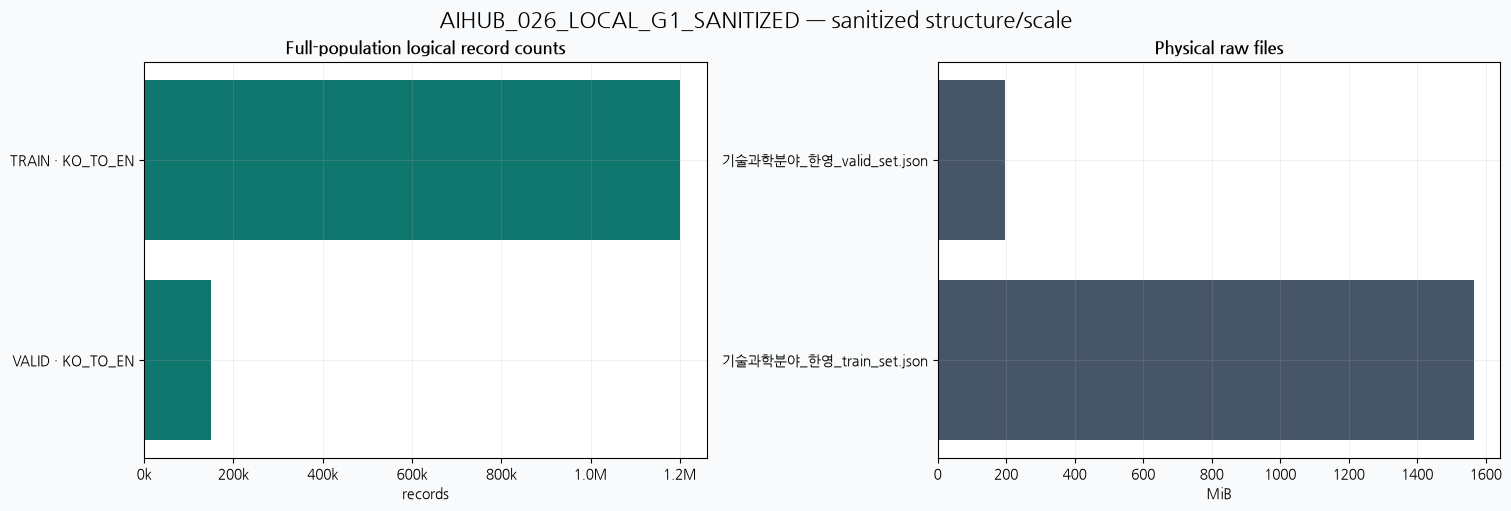

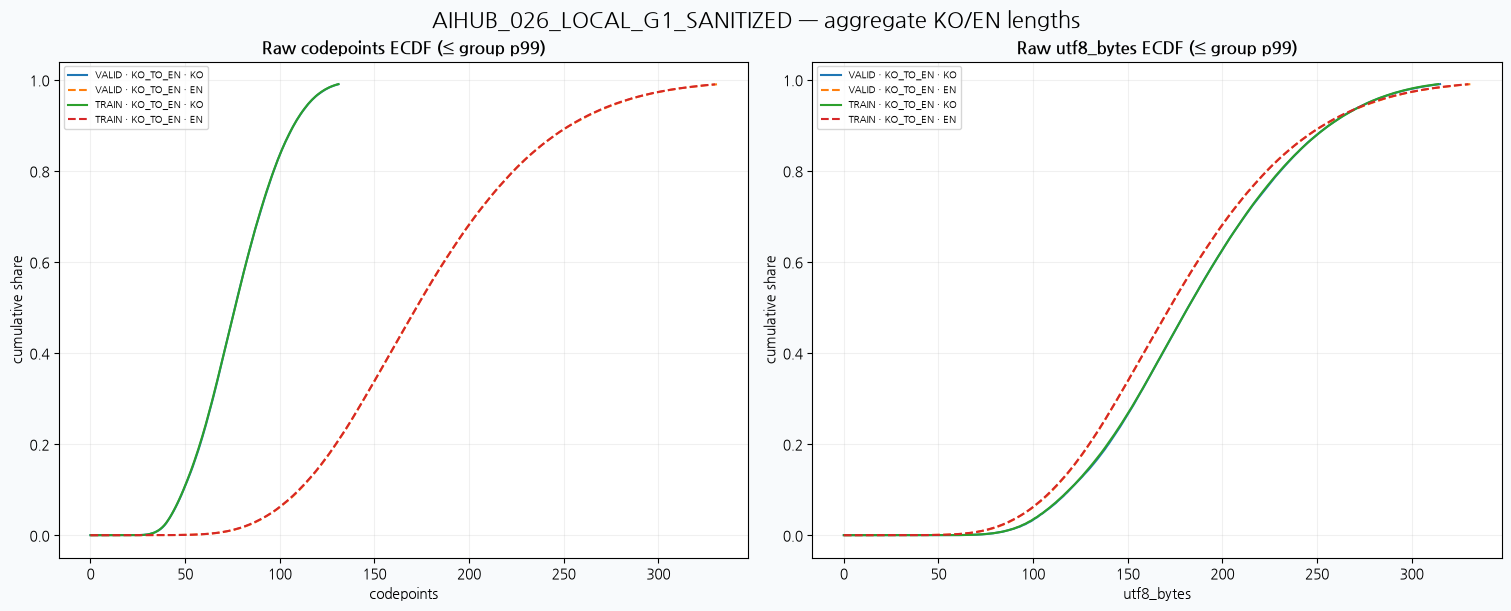

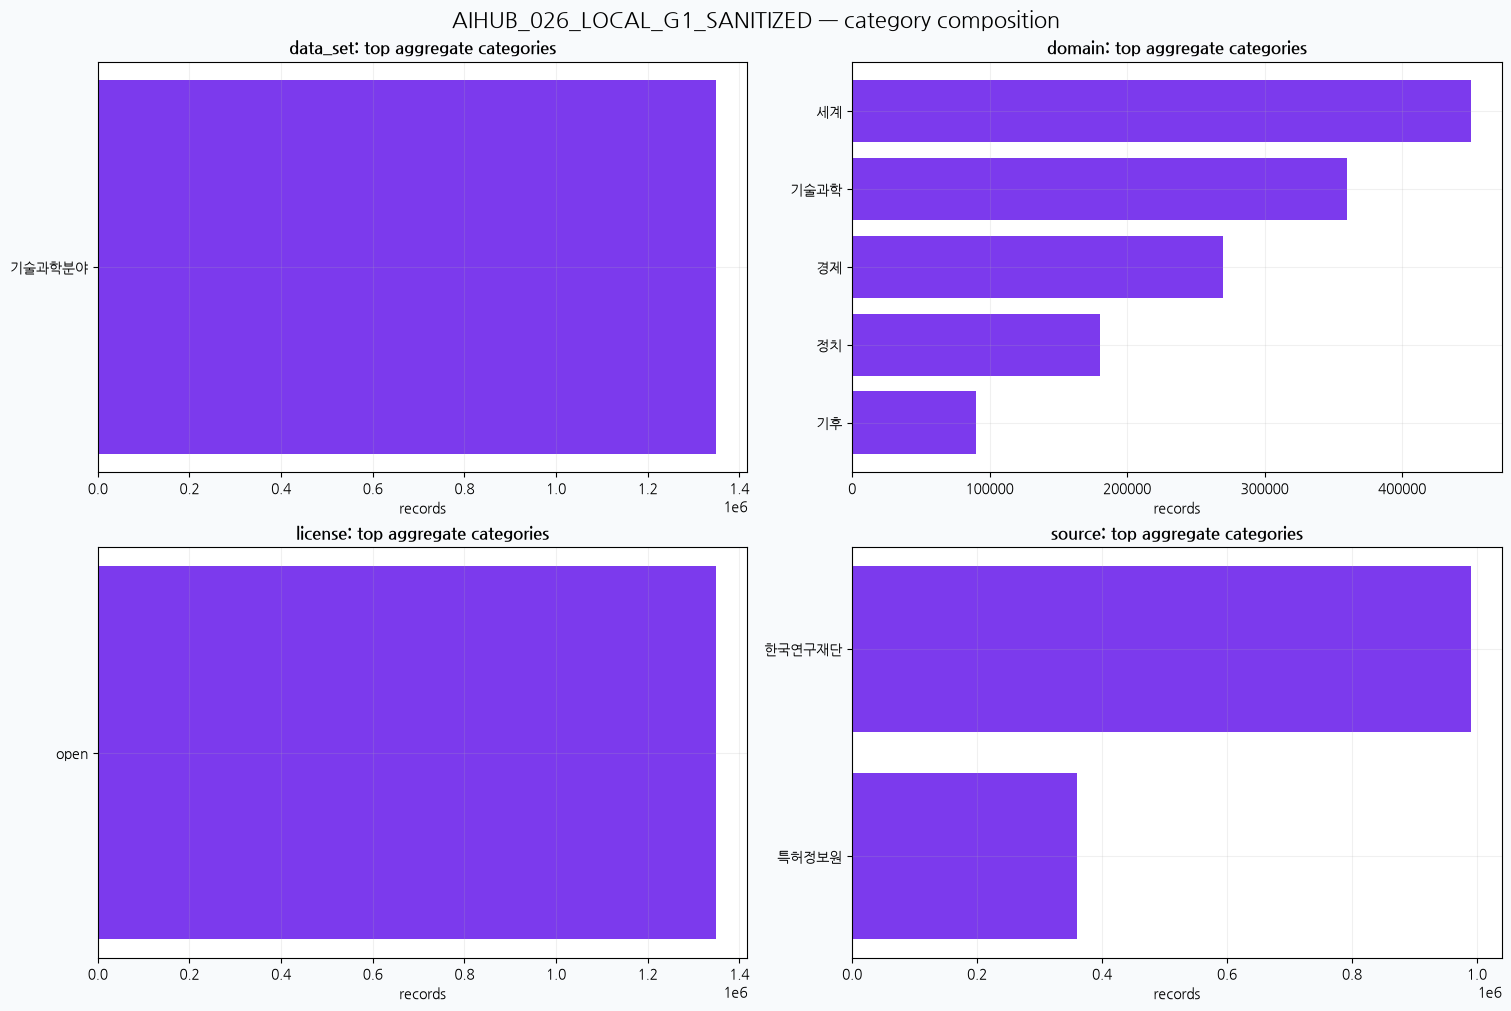

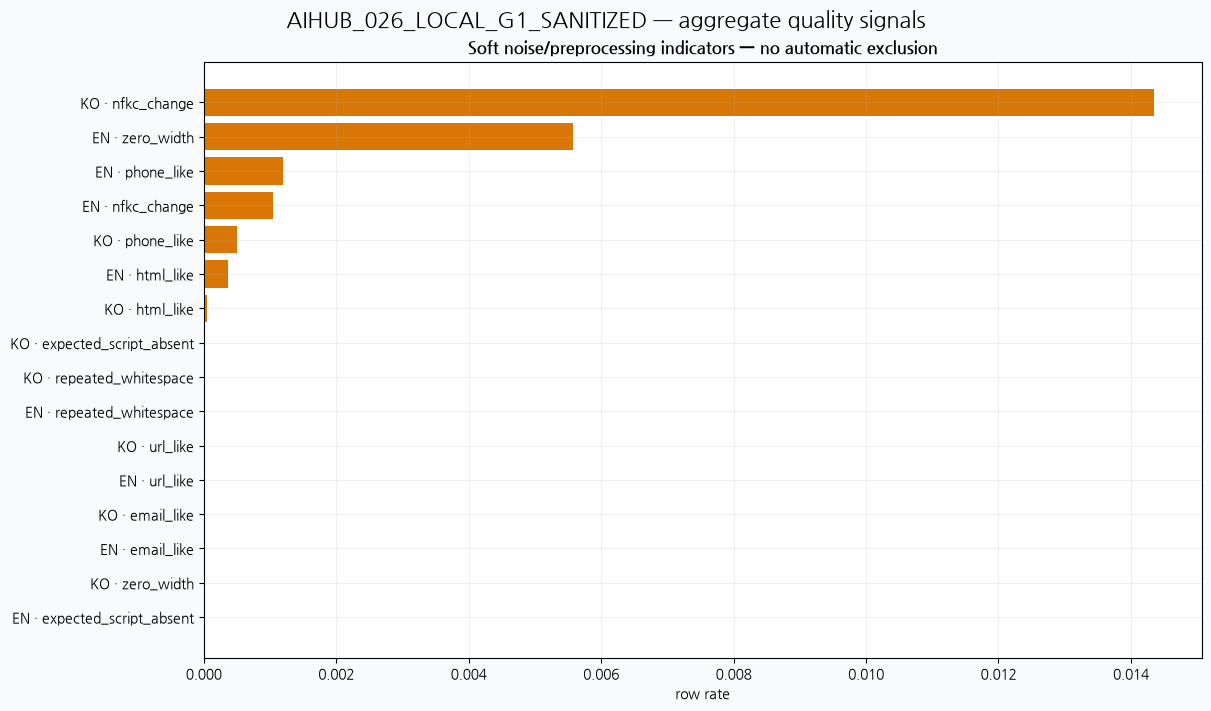

,dataset_local_id,audit_timestamp,audit_completed_timestamp,physical_file_count,profiled_data_file_count,logical_record_count,population_scope,raw_text_exported,text_hash_exported,status
0,AIHUB_026_LOCAL_G1_SANITIZED,2026-08-16T17:26:52+09:00,2026-08-16T17:27:49+09:00,4,2,1350162,FULL_POPULATION_AGGREGATES,False,False,G1_SANITIZED_SUPPORT / NOT QC ACCEPTANCE


,group,records
0,TRAIN · KO_TO_EN,1200144
1,VALID · KO_TO_EN,150018


In [2]:
result = profile_dataset(CONFIG)
profile_paths = save_profile(result, OUTPUT_DIR)
figure_paths = plot_profile(result, FIGURE_DIR)
display(pd.DataFrame([result["summary"]]))
display(result["record_counts"])


## 3. Aggregate structure, length, category, and soft flags

모든 표는 keys, counts, rates, lengths, categories만 포함한다.

In [3]:
display(Markdown("### Schema: keys/types/missingness only"))
display(result["schema"].sort_values(["group", "missing_or_empty_rate"], ascending=[True, False]))
display(Markdown("### Length summaries: aggregate only"))
display(result["length_summary"])
display(Markdown("### Non-sensitive category distributions"))
display(result["categories"].sort_values(["dimension", "record_count"], ascending=[True, False]).groupby("dimension").head(20))
display(Markdown("### Soft noise and duplicate candidates"))
display(result["noise"].sort_values("rate", ascending=False).head(40))
display(result["duplicates"])


### Schema: keys/types/missingness only

,group,field,records,absent,null,empty,missing_or_empty_rate,type_counts,raw_value_exported
9,TRAIN · KO_TO_EN,ner,1200144,0,1003831,0,0.836425,"{""dict"": 196313, ""null"": 1003831}",False
0,TRAIN · KO_TO_EN,data_set,1200144,0,0,0,0.000000,"{""string"": 1200144}",False
1,TRAIN · KO_TO_EN,domain,1200144,0,0,0,0.000000,"{""string"": 1200144}",False
2,TRAIN · KO_TO_EN,en,1200144,0,0,0,0.000000,"{""string"": 1200144}",False
3,TRAIN · KO_TO_EN,file_name,1200144,0,0,0,0.000000,"{""string"": 1200144}",False
4,TRAIN · KO_TO_EN,included_unknown_words,1200144,0,0,0,0.000000,"{""boolean"": 1200144}",False
5,TRAIN · KO_TO_EN,ko,1200144,0,0,0,0.000000,"{""string"": 1200144}",False
6,TRAIN · KO_TO_EN,ko_original,1200144,0,0,0,0.000000,"{""string"": 1200144}",False
7,TRAIN · KO_TO_EN,license,1200144,0,0,0,0.000000,"{""string"": 1200144}",False
8,TRAIN · KO_TO_EN,mt,1200144,0,0,0,0.000000,"{""string"": 1200144}",False


### Length summaries: aggregate only

,group,language,metric,count,min,p50,p90,p95,p99,max,mean
0,TRAIN · KO_TO_EN,EN,codepoints,1200144,1,173,254,279,330,2208,178.462173
1,TRAIN · KO_TO_EN,EN,utf8_bytes,1200144,1,173,254,280,330,2208,178.504153
2,TRAIN · KO_TO_EN,KO,codepoints,1200144,2,77,108,116,131,684,78.093343
3,TRAIN · KO_TO_EN,KO,utf8_bytes,1200144,4,182,257,278,314,1538,186.098959
4,VALID · KO_TO_EN,EN,codepoints,150018,11,173,254,280,331,635,178.542182
5,VALID · KO_TO_EN,EN,utf8_bytes,150018,11,173,254,280,331,635,178.586803
6,VALID · KO_TO_EN,KO,codepoints,150018,7,77,108,116,131,295,78.177839
7,VALID · KO_TO_EN,KO,utf8_bytes,150018,19,182,257,278,315,705,186.293571


### Non-sensitive category distributions

,group,dimension,category,record_count
4,TRAIN · KO_TO_EN,data_set,기술과학분야,1200144
31,VALID · KO_TO_EN,data_set,기술과학분야,150018
7,TRAIN · KO_TO_EN,domain,세계,400123
13,TRAIN · KO_TO_EN,domain,기술과학,319551
9,TRAIN · KO_TO_EN,domain,경제,240439
16,TRAIN · KO_TO_EN,domain,정치,160064
19,TRAIN · KO_TO_EN,domain,기후,79967
40,VALID · KO_TO_EN,domain,세계,49818
34,VALID · KO_TO_EN,domain,기술과학,40359
37,VALID · KO_TO_EN,domain,경제,29705


### Soft noise and duplicate candidates

,group,language,metric,row_count,records,rate,classification
24,VALID · KO_TO_EN,KO,nfkc_change,2182,150018,0.014545,SOFT_OBSERVATION_ONLY
9,TRAIN · KO_TO_EN,KO,nfkc_change,17193,1200144,0.014326,SOFT_OBSERVATION_ONLY
20,VALID · KO_TO_EN,EN,zero_width,840,150018,0.005599,SOFT_OBSERVATION_ONLY
6,TRAIN · KO_TO_EN,EN,zero_width,6688,1200144,0.005573,SOFT_OBSERVATION_ONLY
3,TRAIN · KO_TO_EN,EN,phone_like,1437,1200144,0.001197,SOFT_OBSERVATION_ONLY
18,VALID · KO_TO_EN,EN,phone_like,175,150018,0.001167,SOFT_OBSERVATION_ONLY
17,VALID · KO_TO_EN,EN,nfkc_change,169,150018,0.001127,SOFT_OBSERVATION_ONLY
2,TRAIN · KO_TO_EN,EN,nfkc_change,1237,1200144,0.001031,SOFT_OBSERVATION_ONLY
25,VALID · KO_TO_EN,KO,phone_like,78,150018,0.000520,SOFT_OBSERVATION_ONLY
10,TRAIN · KO_TO_EN,KO,phone_like,600,1200144,0.000500,SOFT_OBSERVATION_ONLY


,scope,records,duplicate_pair_rows_after_first,distinct_duplicate_pair_groups,method,classification
0,local_dataset,1350162,44,44,salted in-memory BLAKE2b-128 exact raw KO+EN; ...,DUPLICATE_CANDIDATE_ONLY


## 4. Targeted decision evidence

source×domain crosstab, patent-source/technology-domain row-level biconditional, and domain-mapping preview.

모든 결과는 structural/local observation이며 causal, exclusion, Tier, QC acceptance 판단이 아니다.

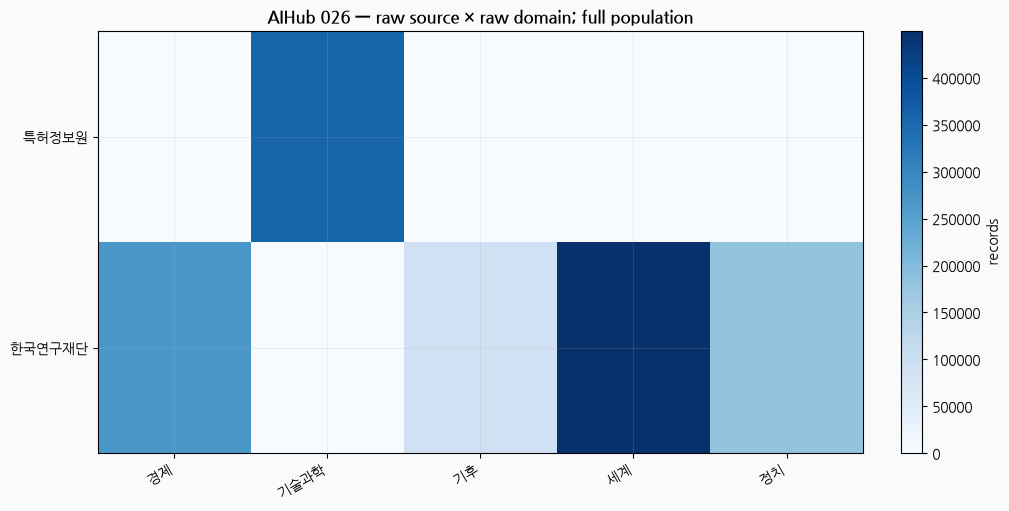

### source_domain_full_population

,raw_source,raw_domain,record_count
2,특허정보원,기술과학,359910
1,한국연구재단,경제,270144
4,한국연구재단,기후,89928
0,한국연구재단,세계,449941
3,한국연구재단,정치,180239


### patent_technology_row_level_check

,patent_source_record_count,technology_domain_record_count,joint_record_count,patent_source_outside_technology_count,technology_domain_outside_patent_source_count,row_level_biconditional_exact,classification
0,359910,359910,359910,0,0,True,LOCAL_CATEGORICAL_BICONDITIONAL_ONLY


### canonical_domain_mapping_preview

,raw_domain,proposed_canonical_domain,record_count
1,경제,other,270144
4,기후,other,89928
0,세계,other,449941
3,정치,other,180239
2,기술과학,technology,359910


In [4]:
targeted = targeted_026(Path(CONFIG['raw_root']), TARGET_OUTPUT_DIR, TARGET_FIGURE_DIR)
for name, frame in targeted.items():
    display(Markdown(f"### {name}"))
    display(frame)


## 5. Interpretation scaffold

관찰:

원인 후보:

제한: local raw aggregate이며 official identity/provenance를 확정하지 않는다.

결론: Research Director reconciliation 전에는 source rank, exclusion, Tier를 결정하지 않는다.

## 6. Export validation

In [5]:
required = profile_paths + figure_paths
for path in required:
    assert path.exists(), path
for frame_name in ["inventory", "record_counts", "schema", "length_summary", "noise", "categories", "duplicates"]:
    frame = result[frame_name]
    assert not {"ko", "en", "ko_preview", "en_preview", "원문", "번역문", "URL"}.intersection(frame.columns)
assert result["summary"]["raw_text_exported"] is False
assert result["summary"]["text_hash_exported"] is False
print("SANITIZED NOTEBOOK PASS")
print("raw text rows exported: 0")
print("text hashes exported: 0")


SANITIZED NOTEBOOK PASS
raw text rows exported: 0
text hashes exported: 0
